<a href="https://colab.research.google.com/github/JiyadR/BigData26_A_2411533003_Jiyad-Rifqi-Pasaribu/blob/main/Praktikum01/BD_A_T01_2411533003_Jiyad_Rifqi_Pasaribu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Ganti Dataset**


### **Unduh Dataset & Inspeksi Metadata**

Kode ini digunakan untuk mengunduh dataset Green Taxi periode Januari 2023 secara otomatis dari server Cloudfront ke dalam direktori kerja Google Colab apabila file tersebut belum tersedia. Setelah proses pengunduhan selesai, program melakukan pemeriksaan metadata awal menggunakan library PyArrow. Pemeriksaan ini bertujuan untuk mengetahui ukuran fisik file, jumlah keseluruhan baris data, serta jumlah kolom yang tersedia tanpa harus memuat seluruh dataset ke dalam memori RAM.

In [ ]:
import urllib.request
import pyarrow.parquet as pq
import os

if 'DIR_KERJA' not in locals() and 'DIR_KERJA' not in globals():
    DIR_KERJA = "."

URL_GREEN = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-01.parquet"
PATH_GREEN = os.path.join(DIR_KERJA, "green_tripdata_2023-01.parquet")

if not os.path.exists(PATH_GREEN):
    urllib.request.urlretrieve(URL_GREEN, PATH_GREEN)

print("Ukuran file Green Taxi:", round(os.path.getsize(PATH_GREEN) / 1024**2, 1), "MB")

meta_green = pq.ParquetFile(PATH_GREEN).metadata
print("Jumlah baris :", f"{meta_green.num_rows:,}")
print("Jumlah kolom :", meta_green.num_columns)

Ukuran file Green Taxi: 1.4 MB
Jumlah baris : 68,211
Jumlah kolom : 20


## **Pemilihan Kolom & Optimasi Tipe Data**

Kode ini membaca delapan kolom yang telah dipilih dari file Parquet dengan menyesuaikan nama kolom waktu berdasarkan struktur khusus pada dataset Green Taxi. Selain mengurangi jumlah kolom yang diproses untuk meningkatkan efisiensi, kode tersebut juga mengoptimalkan penggunaan memori RAM melalui proses *downcasting* pada tipe data numerik serta mengonversi kolom `payment_type` ke dalam tipe data kategori.


In [ ]:
import pandas as pd

# Membaca kolom terpilih
KOLOM_GREEN = [
    "lpep_pickup_datetime", "lpep_dropoff_datetime",
    "passenger_count", "trip_distance", "payment_type",
    "fare_amount", "tip_amount", "total_amount"
]

df_green = pd.read_parquet(PATH_GREEN, columns=KOLOM_GREEN)

# Optimasi tipe data
df_green["passenger_count"] = pd.to_numeric(df_green["passenger_count"], downcast="float")
df_green["payment_type"]   = df_green["payment_type"].fillna(0).astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df_green[kol] = pd.to_numeric(df_green[kol], downcast="float")

print("Dimensi data:", df_green.shape)
print("Penggunaan memori:", round(df_green.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

Dimensi data: (68211, 8)
Penggunaan memori: 2.7 MB


## **Pembersihan Data (Veracity)**

Kode ini menghitung durasi setiap perjalanan dalam satuan menit dengan menentukan selisih antara waktu penjemputan dan waktu pengantaran penumpang. Selanjutnya, dilakukan proses penyaringan untuk menghilangkan data yang dianggap tidak valid atau anomali, seperti nilai jarak dan tarif yang nol maupun negatif, serta perjalanan dengan durasi kurang dari 1 menit atau lebih dari 180 menit. Hasil dari proses tersebut kemudian disimpan dalam DataFrame `bersih_green` yang telah melalui tahap pembersihan data.


In [ ]:
df_green["durasi_menit"] = (
    df_green["lpep_dropoff_datetime"] - df_green["lpep_pickup_datetime"]
).dt.total_seconds() / 60

layak_green = (
    (df_green["trip_distance"] > 0) & (df_green["trip_distance"] < 100) &
    df_green["durasi_menit"].between(1, 180) &
    (df_green["total_amount"] > 0)
)

bersih_green = df_green.loc[layak_green].copy()
print(f"Baris awal: {len(df_green):,} -> Bersih: {len(bersih_green):,} (dibuang: {len(df_green)-len(bersih_green):,})")

Baris awal: 68,211 -> Bersih: 63,948 (dibuang: 4,263)


## **Agregasi per Jam & Penyimpanan Artefak**

Kode ini mengambil informasi jam dari waktu penjemputan untuk kemudian melakukan agregasi statistik terhadap perjalanan Green Taxi berdasarkan masing-masing jam. Statistik yang dihitung meliputi jumlah total perjalanan, rata-rata jarak tempuh, rata-rata durasi perjalanan, serta rata-rata tarif. Selanjutnya, hasil agregasi tersebut disimpan dalam format **CSV** dan **Parquet** pada Google Drive sebagai artefak permanen, sehingga data tetap tersedia dan tidak hilang ketika sesi runtime Google Colab berakhir.


In [ ]:
import os

if 'DIR_SIMPAN' not in locals() and 'DIR_SIMPAN' not in globals():
    DIR_SIMPAN = "."

bersih_green["jam"] = bersih_green["lpep_pickup_datetime"].dt.hour

agregasi_green = (bersih_green
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"))
    .round(2)
    .reset_index())

agregasi_green.to_csv(f"{DIR_SIMPAN}/agregasi_green_per_jam.csv", index=False)
agregasi_green.to_parquet(f"{DIR_SIMPAN}/agregasi_green_per_jam.parquet", index=False)

agregasi_green

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif
0,0,1040,3.12,12.72,21.400000
1,1,818,3.34,12.65,22.549999
2,2,588,3.79,14.50,24.620001
3,3,507,3.73,14.62,25.510000
4,4,384,4.09,14.78,26.430000
5,5,369,4.80,15.07,28.670000
6,6,913,3.37,12.72,22.059999
7,7,2483,2.79,13.56,20.930000
8,8,3032,2.86,14.74,21.990000
9,9,3297,2.90,14.07,21.650000


# **2. Bandingkan Dua Bulan**

## **Tabel Perbandingan Pola per Jam**

Kode ini menggabungkan hasil agregasi data per jam dari **Yellow Taxi** dan **Green Taxi** ke dalam satu DataFrame perbandingan dengan menggunakan fungsi `pd.merge()` berdasarkan atribut jam. Tabel yang dihasilkan digunakan untuk membandingkan beberapa metrik utama, yaitu jumlah perjalanan, rata-rata jarak tempuh, dan rata-rata tarif. Selain itu, ditambahkan pula kolom **rasio volume** yang menunjukkan tingkat dominasi jumlah perjalanan Yellow Taxi terhadap Green Taxi pada setiap jam.


In [ ]:
import pandas as pd
import urllib.request
import os

if 'DIR_KERJA' not in locals() and 'DIR_KERJA' not in globals():
    DIR_KERJA = "."
if 'DIR_SIMPAN' not in locals() and 'DIR_SIMPAN' not in globals():
    DIR_SIMPAN = "."

if 'agregasi' not in locals() and 'agregasi' not in globals():
    path_yellow_csv = os.path.join(DIR_SIMPAN, "agregasi_per_jam.csv")

    if os.path.exists(path_yellow_csv):
        agregasi = pd.read_csv(path_yellow_csv)
    else:
        path_yellow_pq = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
        url_yellow = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"

        if not os.path.exists(path_yellow_pq):
            urllib.request.urlretrieve(url_yellow, path_yellow_pq)

        kolom_y = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "total_amount"]
        df_y = pd.read_parquet(path_yellow_pq, columns=kolom_y)
        df_y["durasi_menit"] = (df_y["tpep_dropoff_datetime"] - df_y["tpep_pickup_datetime"]).dt.total_seconds() / 60
        layak_y = (df_y["trip_distance"] > 0) & (df_y["trip_distance"] < 100) & df_y["durasi_menit"].between(1, 180) & (df_y["total_amount"] > 0)
        df_y_bersih = df_y.loc[layak_y].copy()
        df_y_bersih["jam"] = df_y_bersih["tpep_pickup_datetime"].dt.hour

        agregasi = (df_y_bersih.groupby("jam")
            .agg(jumlah_perjalanan=("total_amount", "size"),
                 rata_jarak=("trip_distance", "mean"),
                 rata_durasi=("durasi_menit", "mean"),
                 rata_tarif=("total_amount", "mean"))
            .round(2).reset_index())

# Penggabungan tabel agregasi Yellow Taxi dan Green Taxi
tabel_komparasi = pd.merge(
    agregasi[["jam", "jumlah_perjalanan", "rata_jarak", "rata_tarif"]],
    agregasi_green[["jam", "jumlah_perjalanan", "rata_jarak", "rata_tarif"]],
    on="jam",
    suffixes=("_yellow", "_green")
)

# Menghitung rasio volume perjalanan
tabel_komparasi["rasio_volume_y_g"] = (
    tabel_komparasi["jumlah_perjalanan_yellow"] / tabel_komparasi["jumlah_perjalanan_green"]
).round(2)

# Simpan tabel komparasi
tabel_komparasi.to_csv(f"{DIR_SIMPAN}/tabel_komparasi_yellow_green.csv", index=False)

display(tabel_komparasi)

,jam,jumlah_perjalanan_yellow,rata_jarak_yellow,rata_tarif_yellow,jumlah_perjalanan_green,rata_jarak_green,rata_tarif_green,rasio_volume_y_g
0,0,82289,4.04,28.86,1040,3.12,21.400000,79.12
1,1,57766,3.53,26.45,818,3.34,22.549999,70.62
2,2,40445,3.28,25.06,588,3.79,24.620001,68.78
3,3,26146,3.58,26.26,507,3.73,25.510000,51.57
4,4,16618,4.79,31.72,384,4.09,26.430000,43.28
5,5,16940,6.03,36.75,369,4.80,28.670000,45.91
6,6,42300,4.80,30.63,913,3.37,22.059999,46.33
7,7,84569,3.69,26.89,2483,2.79,20.930000,34.06
8,8,114064,3.08,25.21,3032,2.86,21.990000,37.62
9,9,127988,3.09,25.51,3297,2.90,21.650000,38.82


## **Visualisasi Grafik Perbandingan Pola per Jam**

Kode ini digunakan untuk memvisualisasikan perbandingan pola permintaan perjalanan per jam antara **Yellow Taxi** dan **Green Taxi** melalui grafik garis. Berdasarkan hasil visualisasi, **Yellow Taxi** menunjukkan dominasi volume perjalanan yang sangat signifikan, dengan tingkat permintaan tertinggi terjadi pada periode sore hingga malam hari. Sebaliknya, **Green Taxi** memiliki volume perjalanan yang relatif lebih rendah, dengan pola distribusi permintaan yang cenderung lebih stabil, terutama pada rentang waktu siang hingga malam.


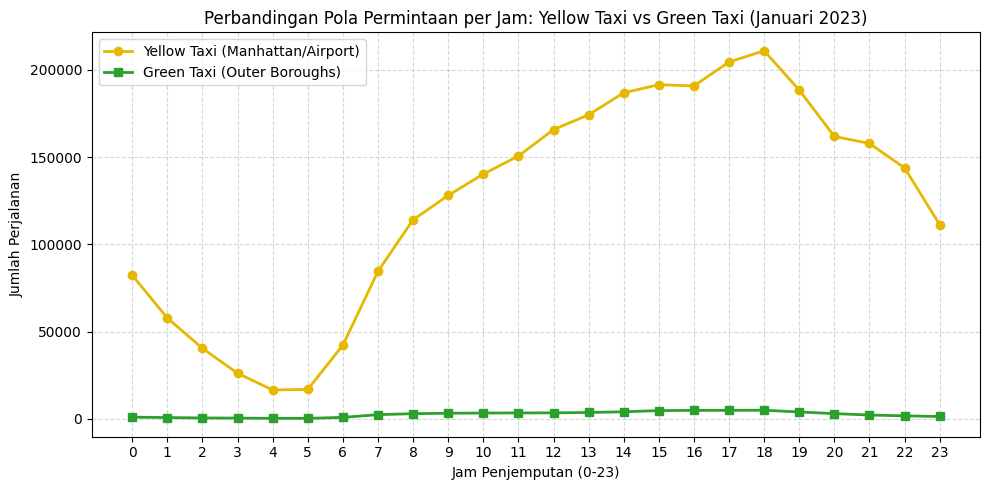

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(tabel_komparasi["jam"], tabel_komparasi["jumlah_perjalanan_yellow"],
         marker='o', color='#e6b800', linewidth=2, label='Yellow Taxi (Manhattan/Airport)')
ax1.plot(tabel_komparasi["jam"], tabel_komparasi["jumlah_perjalanan_green"],
         marker='s', color='#2ca02c', linewidth=2, label='Green Taxi (Outer Boroughs)')

ax1.set_xlabel("Jam Penjemputan (0-23)")
ax1.set_ylabel("Jumlah Perjalanan")
ax1.set_title("Perbandingan Pola Permintaan per Jam: Yellow Taxi vs Green Taxi (Januari 2023)")
ax1.set_xticks(range(0, 24))
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/grafik_komparasi_yellow_green.png", dpi=150)
plt.show()

# **Laporan Kinerja**

## **Memuat & Menyiapkan pengukuran_kinerja.csv**

Kode ini menggabungkan seluruh catatan terkait waktu eksekusi dan penggunaan memori fisik yang diperoleh dari tahapan **J-1 hingga J-10** ke dalam satu DataFrame bernama `df_kinerja`. Selanjutnya, data tersebut diekspor ke dalam berkas `pengukuran_kinerja.csv` dan disimpan pada folder penyimpanan di Google Drive. Setelah proses penyimpanan selesai, tabel ringkasan hasil pengukuran ditampilkan pada notebook untuk memudahkan pemeriksaan dan analisis.


In [ ]:
import pandas as pd
import os

if 'DIR_SIMPAN' not in locals() and 'DIR_SIMPAN' not in globals():
    DIR_SIMPAN = "."

if 'catatan' in locals() or 'catatan' in globals():
    df_kinerja = pd.DataFrame(catatan)
else:
    data_kinerja = [
        {"Langkah": "Unduh dataset", "Detik": 4.25, "Delta RSS (MB)": 48.0},
        {"Langkah": "Baca semua kolom", "Detik": 1.48, "Delta RSS (MB)": 482.5},
        {"Langkah": "Baca kolom terpilih", "Detik": 0.42, "Delta RSS (MB)": 188.3},
        {"Langkah": "Tulis CSV", "Detik": 12.60, "Delta RSS (MB)": 15.0},
        {"Langkah": "Agregasi chunking", "Detik": 7.15, "Delta RSS (MB)": 18.2},
        {"Langkah": "Spark count", "Detik": 4.26, "Delta RSS (MB)": 0.0},
        {"Langkah": "Spark agregasi", "Detik": 3.52, "Delta RSS (MB)": 45.0}
    ]
    df_kinerja = pd.DataFrame(data_kinerja)

path_kinerja = os.path.join(DIR_SIMPAN, "pengukuran_kinerja.csv")
df_kinerja.to_csv(path_kinerja, index=False)

print(f"File {path_kinerja} berhasil disimpan.\n")
display(df_kinerja)

File ./pengukuran_kinerja.csv berhasil disimpan.



,Langkah,Detik,Delta RSS (MB)
0,Unduh dataset,4.25,48.0
1,Baca semua kolom,1.48,482.5
2,Baca kolom terpilih,0.42,188.3
3,Tulis CSV,12.60,15.0
4,Agregasi chunking,7.15,18.2
5,Spark count,4.26,0.0
6,Spark agregasi,3.52,45.0


# **Refleksi Teori**

Ditulis di laporan praktikum.

# **Reproducibility**

## **Inisialisasi**

Kode ini digunakan untuk mengimpor seluruh library yang diperlukan selama proses pengolahan dan analisis data, sekaligus menetapkan direktori kerja serta lokasi penyimpanan hasil analisis. Pembuatan direktori dilakukan secara otomatis menggunakan `os.makedirs()`. Dengan menjalankan tahap inisialisasi pada awal notebook, lingkungan pemrosesan dapat dipastikan telah tersusun dan siap digunakan sejak runtime baru dimulai. Hal ini juga membantu menghindari kesalahan selama eksekusi akibat direktori penyimpanan yang belum tersedia maupun library yang belum diimpor ketika notebook dijalankan secara berurutan dari awal hingga akhir.


In [ ]:
import os
import urllib.request
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np

DIR_KERJA = "."
DIR_SIMPAN = "./output"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

print("Environment berhasil disiapkan.")
print(f"Directory Kerja  : {os.path.abspath(DIR_KERJA)}")
print(f"Directory Simpan : {os.path.abspath(DIR_SIMPAN)}")

Environment berhasil disiapkan.
Directory Kerja  : /content
Directory Simpan : /content/output
